# `DDI-LLM:`
**Exploring Language-based Drug Chemical Structure Embedding Methods for Drug-Drug Interaction Prediction via Graph Convolutional Networks**
---
`Drug-drug interactions (DDIs)` can arise when multiple drugs are used to treat complex or concurrent medical conditions, potentially leading to alterations in how these drugs work. Consequently, predicting DDIs has become a crucial endeavour within medical machine learning, addressing a critical aspect of healthcare.

This paper explores the application of language-based embeddings, including `BERT`, `GPT`,`LLaMA`, and `LLaMA2,` within the context of `Graph Convolutional Networks (GCN)` to enhance DDI prediction.

We start by harnessing these advanced language models to generate embeddings for drug chemical structures and drug descriptions, providing a more comprehensive representation of drug characteristics. These embeddings are subsequently integrated into a DDI network, with GCN employed for link prediction. We utilize BERT, GPT, and LLaMA embeddings to improve the accuracy and effectiveness of predicting drug interactions within this network.

Our experiments reveal that using language-based drug embeddings in combination with DDI structure embeddings can yield accuracy levels comparable to state-of-the-art methods in DDI prediction.






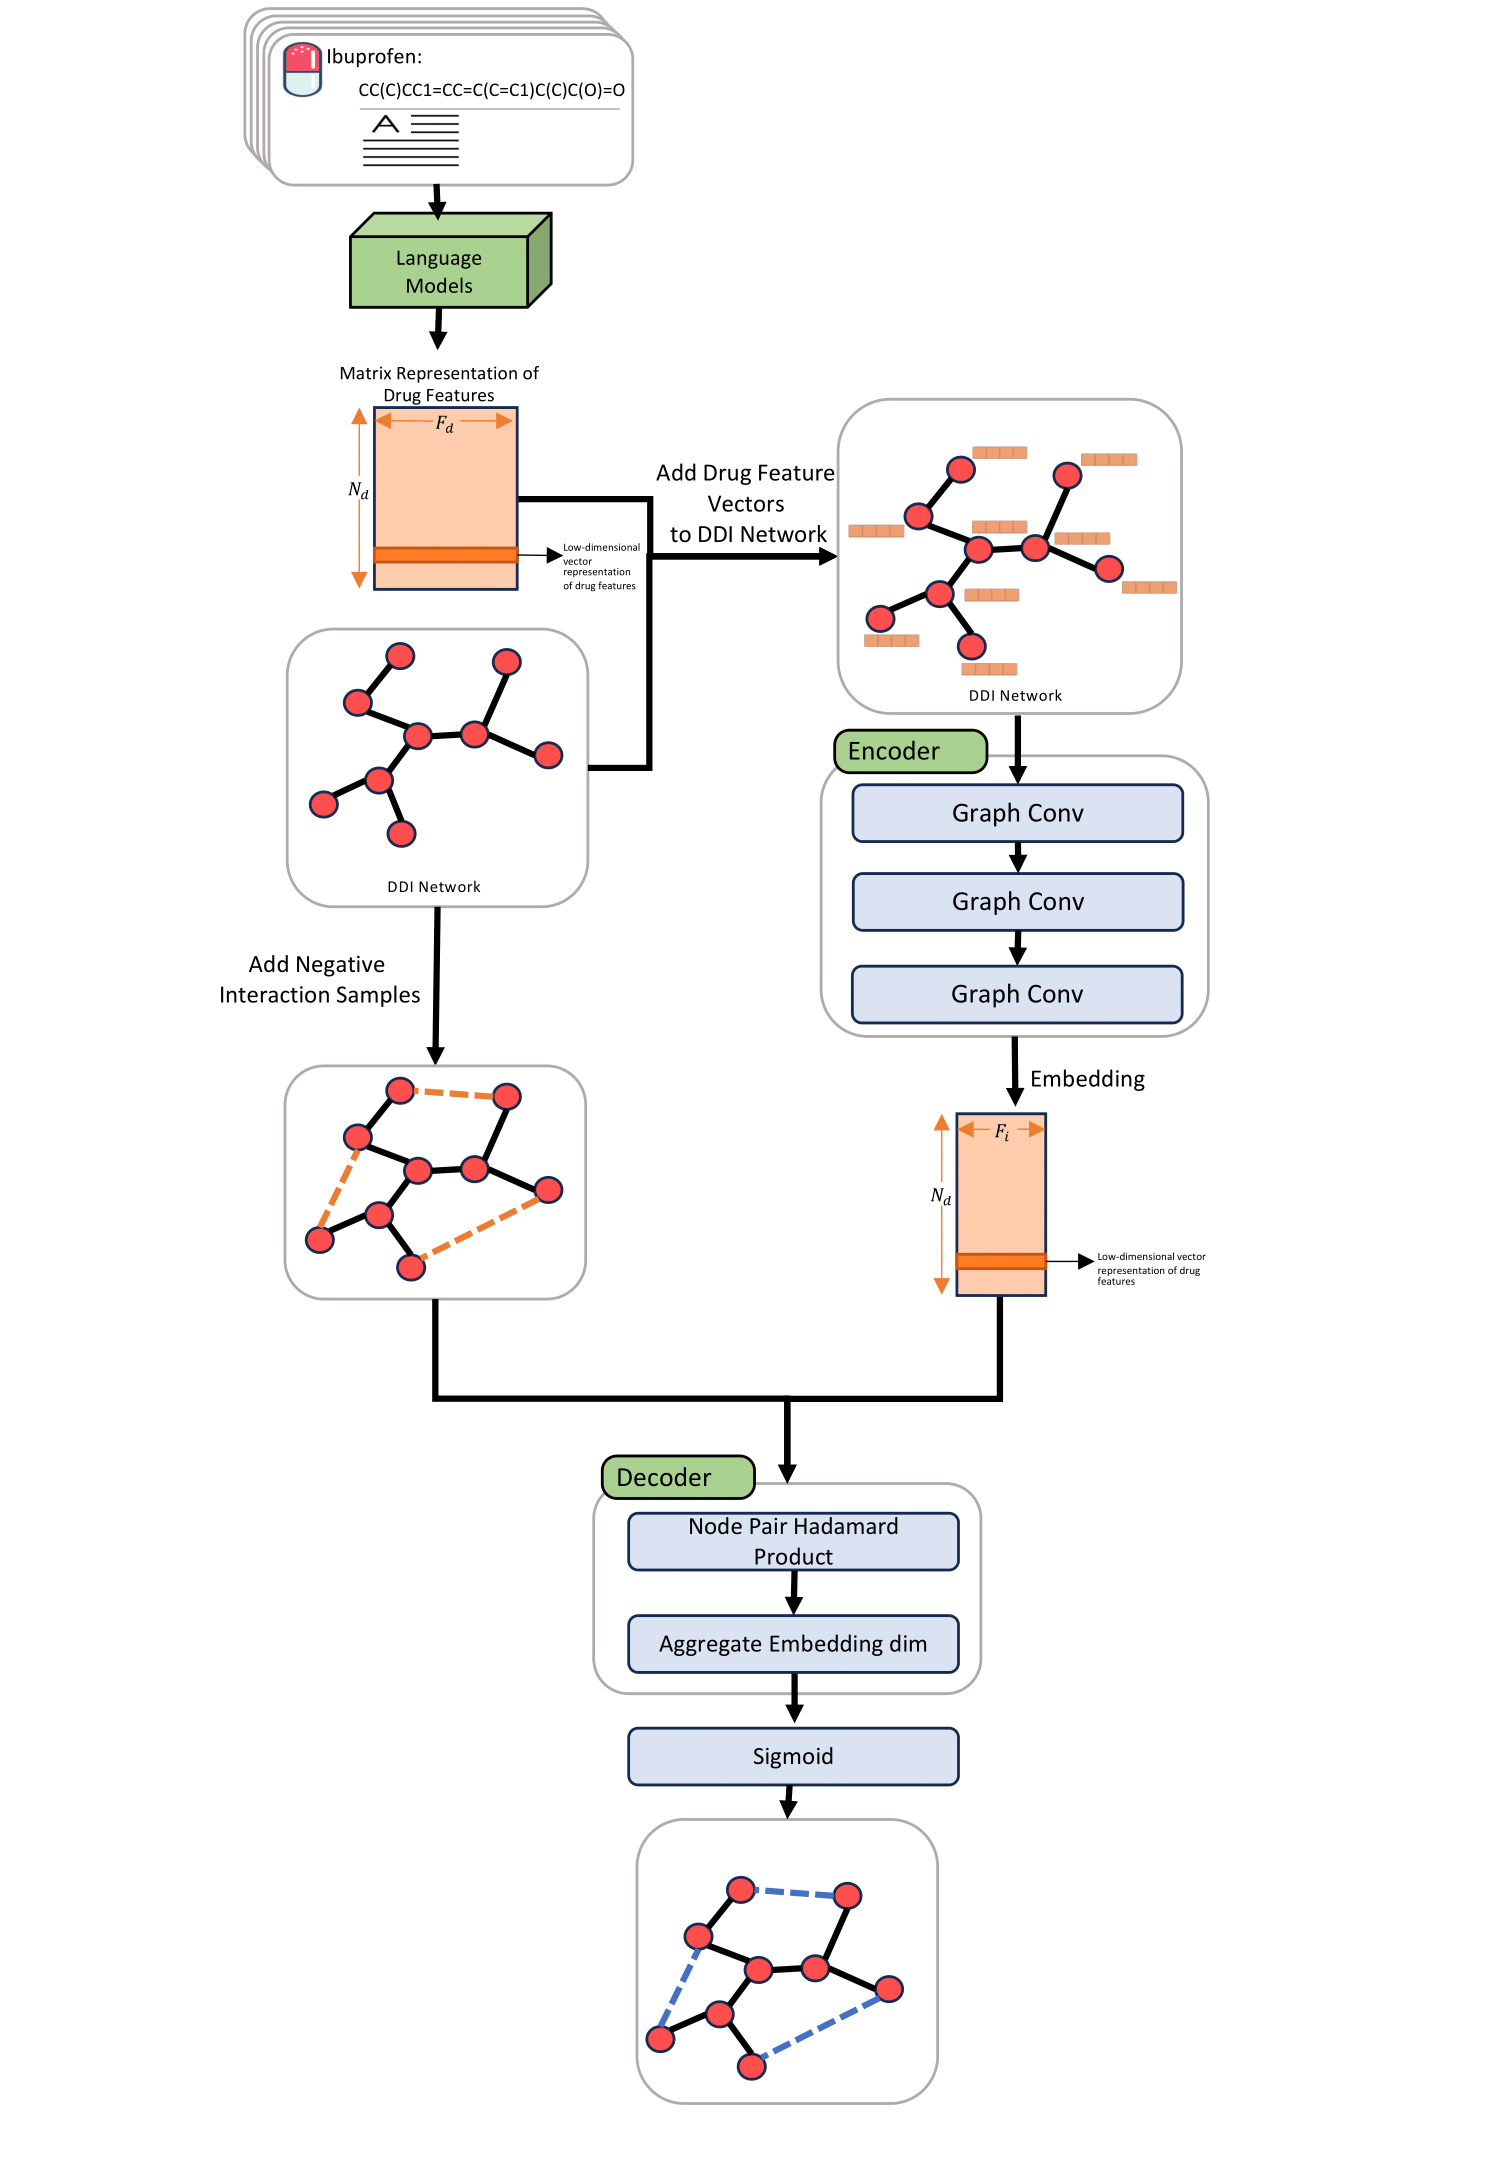


## 1-   Setup



You need to have `Python >= 3.8` and install the following main packages:

In [ ]:
%%capture
!pip install torch==2.0.0
!pip install torch_geometric
!pip install torch_scatter torch_sparse torch_cluster torch_spline_conv -f https://data.pyg.org/whl/torch-2.0.0+cpu.html
!pip install  deepchem
!pip install rdkit
!pip install gensim
!pip install git+https://github.com/samoturk/mol2vec
!pip install transformers


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import random
import os.path as osp
from rdkit import Chem
import deepchem as dc
from deepchem.feat.smiles_tokenizer import BasicSmilesTokenizer
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


from torch_geometric.data import Data
from torch_geometric.transforms import RandomLinkSplit
import torch_geometric.transforms as T
from torch_geometric.utils import negative_sampling, convert, to_dense_adj,structured_negative_sampling
from torch_geometric.nn import GCNConv, SAGEConv
from torch_geometric.nn.conv import MessagePassing

import torch
import torch.nn.functional as F
from torch.optim.lr_scheduler import ExponentialLR,MultiplicativeLR
from torch import Tensor
from torch.utils.data import DataLoader

from gensim.models import word2vec
from gensim.models import Word2Vec
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
import pickle

from mol2vec.features import mol2alt_sentence, mol2sentence, MolSentence, DfVec
import torch
from sklearn.metrics import roc_auc_score ,auc,precision_recall_curve,f1_score

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

Instructions for updating:
experimental_relax_shapes is deprecated, use reduce_retracing instead


In [ ]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')


## 2- Reading DDI dataset
---

This code read two data files, one for `DDI graph` and one for `drug info`. We take the intersection of the datasets, resulting a graph where each node has `SMILES`, `drug name`, and `drug description`.


Input data:

* DDI network: It is a graph where nodes are drug IDs. There are 48514 edges, about `1514` unique `drugIDs`. Raw data from [`BioSnap`](https://snap.stanford.edu/biodata/datasets/10001/10001-ChCh-Miner.html)

Ref: [`MIRACLE`](https://arxiv.org/pdf/2010.11711.pdf)
* `Drug ID-SMILES:` 11583 pairs of (DrugID, SMILES). [`DrugBank`](https://go.drugbank.com/releases/latest#structures)
* `Drug ID-Desc:` 15235 pairs of (DrugID, SMILES) that we extracted from the DrugBANK database.

* **`NOTE:`** Certain SMILES strings in our drug dataset do not represent valid molecules, as determined by the RDKit library. Consequently, to maintain the accuracy and reliability of our graphs, we must exclude these drugs that lack valid information.

In [ ]:
DDI_graph = pd.read_csv('https://raw.githubusercontent.com/liiniix/BioSNAP/master/ChCh-Miner/ChCh-Miner_durgbank-chem-chem.tsv', sep='\t')
#DDI_graph = pd.read_csv('https://raw.githubusercontent.com/sshaghayeghs/molSMILES/main/drugbankDDI.csv', sep=',')

#save the raw data as our own data so that we do not depend on other apis.
DDI_graph.rename(columns={'Drug1': 'src', 'Drug2': 'dst'}, inplace=True)
DrugIDs_in_graph = np.unique(DDI_graph.values) # there are 1514 unique drugs in the graph

DDI_graph

,src,dst
0,DB00862,DB00966
1,DB00575,DB00806
2,DB01242,DB08893
3,DB01151,DB08883
4,DB01235,DB01275
...,...,...
48509,DB00542,DB01354
48510,DB00476,DB01239
48511,DB00621,DB01120
48512,DB00808,DB01356


### 2-1- Properties of the BioSnap graph
* The largest connected components has `1510` nodes in it
* Number of nodes: `1514`
* Number of edges: `48514`
* Is undirected: `True`
* Average node degree: `64.087`
* Has isolated nodes: `False`
* Has self-loops: `False`


In [ ]:
G = nx.from_pandas_edgelist(DDI_graph, 'src', 'dst')

In [ ]:
# Find the connected components
connected_components = nx.connected_components(G)

for component in connected_components:
    subgraph = G.subgraph(component)
    print("Subgraph Nodes:", subgraph.nodes())
    print("Subgraph Edges:", subgraph.edges())
    print("Subgraph Length:", len(subgraph))
    print()

Subgraph Nodes: ['DB00862', 'DB00966', 'DB00575', 'DB00806', 'DB01242', 'DB08893', 'DB01151', 'DB08883', 'DB01235', 'DB01275', 'DB00018', 'DB00333', 'DB00201', 'DB01609', 'DB00712', 'DB01418', 'DB01576', 'DB04842', 'DB06212', 'DB01232', 'DB09291', 'DB00382', 'DB06153', 'DB01017', 'DB01142', 'DB00214', 'DB01174', 'DB00104', 'DB00908', 'DB00569', 'DB01109', 'DB01222', 'DB09063', 'DB00898', 'DB01589', 'DB00762', 'DB09054', 'DB00780', 'DB01158', 'DB00186', 'DB09071', 'DB01248', 'DB06688', 'DB00484', 'DB00881', 'DB00396', 'DB00682', 'DB00368', 'DB01551', 'DB00054', 'DB00605', 'DB01320', 'DB09061', 'DB01167', 'DB00572', 'DB00921', 'DB09272', 'DB01026', 'DB08865', 'DB00999', 'DB01114', 'DB09042', 'DB00041', 'DB00381', 'DB00717', 'DB06404', 'DB00673', 'DB08918', 'DB01215', 'DB00072', 'DB00305', 'DB01100', 'DB06201', 'DB01095', 'DB01393', 'DB09072', 'DB00983', 'DB01223', 'DB00865', 'DB01623', 'DB00211', 'DB00316', 'DB00422', 'DB00876', 'DB00366', 'DB01189', 'DB00997', 'DB04905', 'DB00177', 'DB0

In [ ]:
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
is_undirected = G.is_directed() is False
average_node_degree = sum(dict(G.degree()).values()) / num_nodes

has_isolated_nodes = any(deg == 0 for _, deg in G.degree())
has_self_loops = any(G.has_edge(n, n) for n in G.nodes())

print(f"Number of nodes: {num_nodes}")
print(f"Number of edges: {num_edges}")
print(f"Is undirected: {is_undirected}")
print(f"Average node degree: {average_node_degree}")
print(f"Has isolated nodes: {has_isolated_nodes}")
print(f"Has self-loops: {has_self_loops}")

Number of nodes: 1514
Number of edges: 48514
Is undirected: True
Average node degree: 64.08718626155878
Has isolated nodes: False
Has self-loops: False


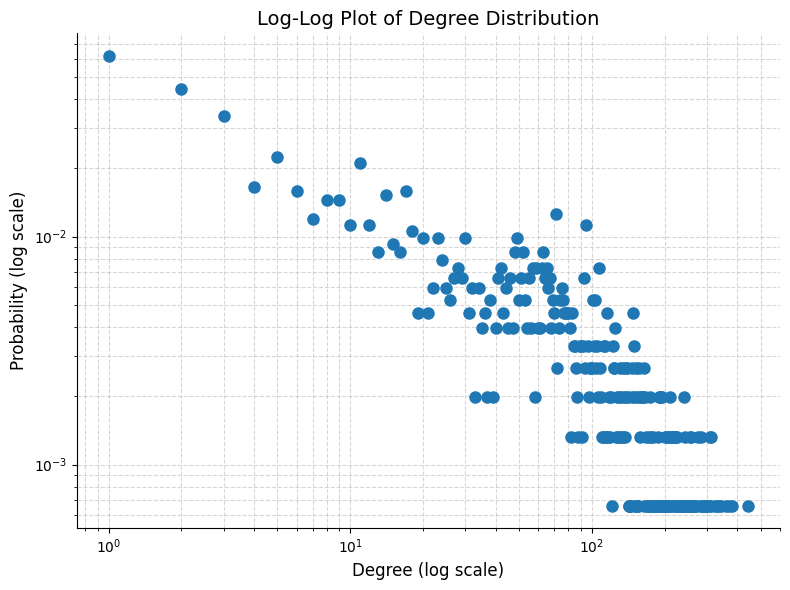

In [ ]:
degrees = dict(G.degree())
degree_values = list(degrees.values())
hist, bins = np.histogram(degree_values, bins=range(1, max(degree_values) + 2), density=True)

plt.figure(figsize=(8, 6))

plt.loglog(bins[:-1], hist, 'o', markersize=8, color='#1f77b4')
plt.title("Log-Log Plot of Degree Distribution", fontsize=14)
plt.xlabel("Degree (log scale)", fontsize=12)
plt.ylabel("Probability (log scale)", fontsize=12)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.savefig("Log-Log Plot of Degree Distribution_biosnap.pdf", format="pdf", bbox_inches="tight")
plt.show()


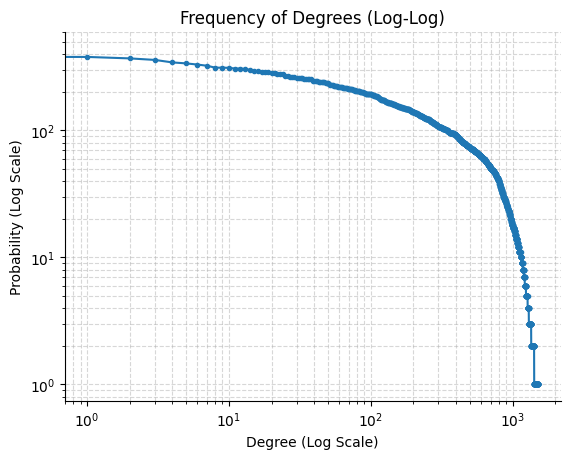

In [ ]:
degrees = dict(G.degree())
degree_values = list(degrees.values())
sorted_values = sorted(degrees.values(), reverse=True)
plt.loglog(sorted_values, marker='o', markersize=3, color='#1f77b4', linestyle='-')
plt.title('Frequency of Degrees (Log-Log)')
plt.xlabel('Degree (Log Scale)')
plt.ylabel('Probability (Log Scale)')
plt.grid(True, which='both', linestyle='--', alpha=0.5)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.savefig("Log-Log Plot of Frequency of Degrees_biosnap.pdf", format="pdf", bbox_inches="tight")
plt.show()

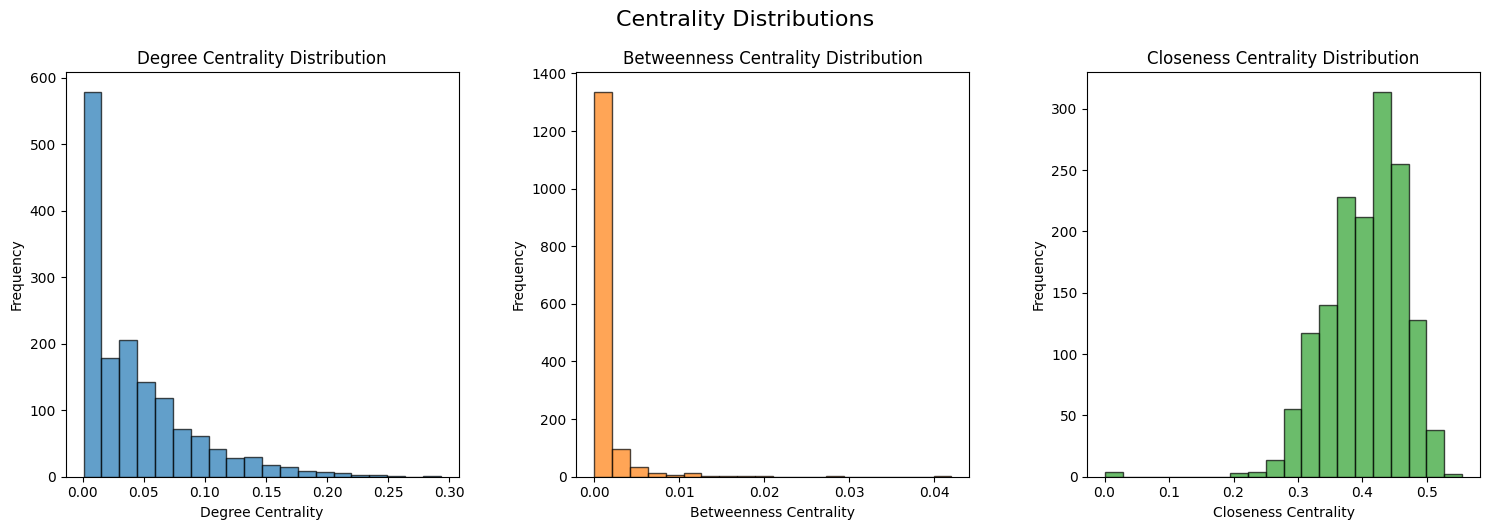

In [ ]:
degree_centrality = nx.degree_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G)
closeness_centrality = nx.closeness_centrality(G)

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']


fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Degree Centrality Distribution
axs[0].hist(list(degree_centrality.values()), bins=20, color=colors[0], alpha=0.7, edgecolor='black')
axs[0].set_title('Degree Centrality Distribution')
axs[0].set_xlabel('Degree Centrality')
axs[0].set_ylabel('Frequency')

# Betweenness Centrality Distribution
axs[1].hist(list(betweenness_centrality.values()), bins=20, color=colors[1], alpha=0.7, edgecolor='black')
axs[1].set_title('Betweenness Centrality Distribution')
axs[1].set_xlabel('Betweenness Centrality')
axs[1].set_ylabel('Frequency')

# Closeness Centrality Distribution
axs[2].hist(list(closeness_centrality.values()), bins=20, color=colors[2], alpha=0.7, edgecolor='black')
axs[2].set_title('Closeness Centrality Distribution')
axs[2].set_xlabel('Closeness Centrality')
axs[2].set_ylabel('Frequency')

plt.tight_layout()

fig.suptitle('Centrality Distributions', fontsize=16, y=1.05)
plt.subplots_adjust(wspace=0.3)
plt.savefig("Centrality Distributions_biosnap.pdf", format="pdf", bbox_inches="tight")

plt.show()

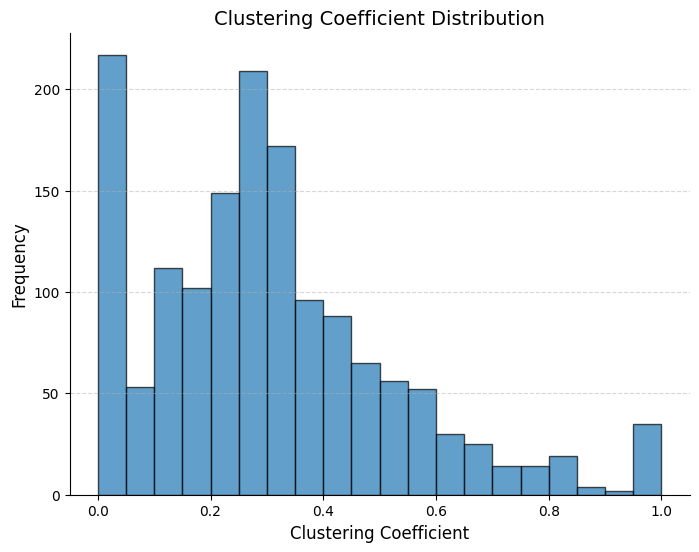

In [ ]:
clustering_coefficients = nx.clustering(G)

# Set a custom color
color = '#1f77b4'

# Create a figure
plt.figure(figsize=(8, 6))

# Plot Clustering Coefficient Distribution
plt.hist(list(clustering_coefficients.values()), bins=20, color=color, alpha=0.7, edgecolor='black')
plt.title('Clustering Coefficient Distribution', fontsize=14)
plt.xlabel('Clustering Coefficient', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Customize tick label font size
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Add grid lines
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Remove top and right spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.savefig("Clustering Coefficient Distribution_biosnap.pdf", format="pdf", bbox_inches="tight")

plt.show()


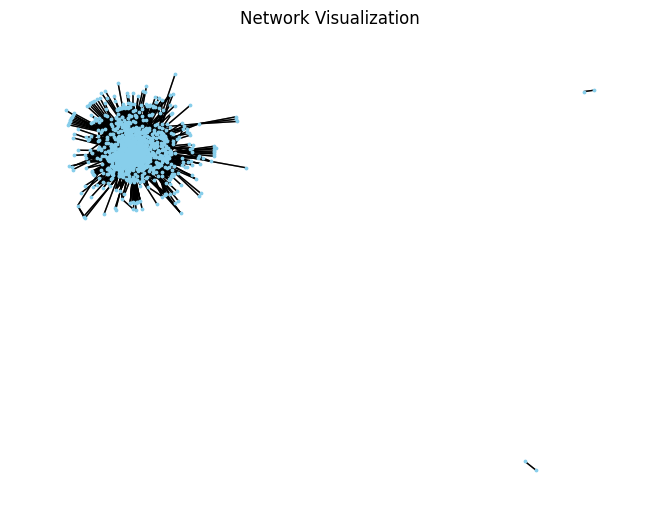

In [ ]:
pos = nx.spring_layout(G)

nx.draw(G, pos, with_labels=False, node_size=3, node_color='skyblue')
nx.draw_networkx_edges(G, pos, alpha=0.5)

plt.title('Network Visualization')
plt.show()

`edge_index` is an important property that we will need for building GNNs. It is a list of edges with shape `[2, |E|]`. Important: since `ddi_graph` is undirected, $E$ includes both $(u, v)$ and $(v, u)$ for two drugs $u$ and $v$ that interact.

Note that there are no node features, so we will need to address this when building our model.

### 2-2-Reading the SMILES strings
---

In [ ]:
drugsSMILES = pd.read_csv('https://raw.githubusercontent.com/sshaghayeghs/molSMILES/main/structure%20links%202.csv')
drugID_smiles = drugsSMILES[["DrugBank ID", "SMILES"]]
drugID_smiles.dropna(inplace=True)
drugID_smiles.reset_index(drop=True, inplace=True)

<ipython-input-10-26bacc5df7ac>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  drugID_smiles.dropna(inplace=True)


### 2-3- Reading Drug Description

In [ ]:
drugsDESC = pd.read_csv('https://raw.githubusercontent.com/sshaghayeghs/molSMILES/main/Drug_description.csv')
drugID_DESC = drugsDESC[["Drug ID", "Discription"]]
drugID_DESC.dropna(inplace=True)
drugID_DESC.reset_index(drop=True, inplace=True)

<ipython-input-11-c2147157fec6>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  drugID_DESC.dropna(inplace=True)


### 2-4- Cleaning the DDI network
Droping drugs with `invalid` smiles strings

* In our `drugID_smiles` dataset, some `SMILES` strings do not correspond to valid molecules according to `RDKit`. Our goal is to ensure the integrity of our ddi network by removing these non-valid drugs.

* Droping the drugs that do not have any correspond drug description.

In [ ]:
#checking if a molecule has a valid molecule corespodn to the smiles string
def is_valid_molecule(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        return mol is not None
    except:
        return False

In [ ]:
valid_smiles = pd.DataFrame(drugID_smiles)
valid_smiles['IsValidMolecule'] = drugID_smiles['SMILES'].apply(is_valid_molecule)
df_valid_molecules = valid_smiles[valid_smiles['IsValidMolecule']]

# Drop the temporary 'IsValidMolecule' column
df_valid_molecules = df_valid_molecules.drop(columns=['IsValidMolecule'])

[00:34:43] Explicit valence for atom # 13 Cl, 5, is greater than permitted
[00:34:43] SMILES Parse Error: syntax error while parsing: OS(O)(O)C1=CC=C(C=C1)C-1=C2\C=CC(=N2)\C(=C2/N\C(\C=C2)=C(/C2=N/C(/C=C2)=C(\C2=CC=C\-1N2)C1=CC=C(C=C1)S(O)(O)O)C1=CC=C(C=C1)S([O-])([O-])[O-])\C1=CC=C(C=C1)S(O)(O)[O-]
[00:34:43] SMILES Parse Error: Failed parsing SMILES 'OS(O)(O)C1=CC=C(C=C1)C-1=C2\C=CC(=N2)\C(=C2/N\C(\C=C2)=C(/C2=N/C(/C=C2)=C(\C2=CC=C\-1N2)C1=CC=C(C=C1)S(O)(O)O)C1=CC=C(C=C1)S([O-])([O-])[O-])\C1=CC=C(C=C1)S(O)(O)[O-]' for input: 'OS(O)(O)C1=CC=C(C=C1)C-1=C2\C=CC(=N2)\C(=C2/N\C(\C=C2)=C(/C2=N/C(/C=C2)=C(\C2=CC=C\-1N2)C1=CC=C(C=C1)S(O)(O)O)C1=CC=C(C=C1)S([O-])([O-])[O-])\C1=CC=C(C=C1)S(O)(O)[O-]'
[00:34:43] Explicit valence for atom # 19 O, 3, is greater than permitted
[00:34:43] Explicit valence for atom # 0 O, 3, is greater than permitted
[00:34:43] Unusual charge on atom 0 number of radical electrons set to zero
[00:34:43] Explicit valence for atom # 4 F, 2, is greater than permitted
[

In [ ]:

allowed_drug=[list(df_valid_molecules['DrugBank ID']),list(drugID_DESC['Drug ID'])]
# There are 1278 drugIDs that occur in the graph. Some graph nodes do not have associated SMILES or drug description

#droping the links that do not have any SMILES
for l in allowed_drug:
  for index, row in DDI_graph.iterrows():
      # Check if both cells in the row are in the allowed cells list
      if row['src'] not in l or row['dst'] not in l:
          # If either cell is not in the allowed cells list, remove the row
          DDI_graph.drop(index, inplace=True)



In [ ]:
#27800 edges
DDI_graph=DDI_graph.reset_index(drop=True)


In [ ]:
G = nx.from_pandas_edgelist(DDI_graph, 'src', 'dst')

In [ ]:
# Find the connected components
connected_components = nx.connected_components(G)

for component in connected_components:
    subgraph = G.subgraph(component)
    print("Subgraph Nodes:", subgraph.nodes())
    print("Subgraph Edges:", subgraph.edges())
    print("Subgraph Length:", len(subgraph))
    print()

Subgraph Nodes: ['DB00862', 'DB00966', 'DB00575', 'DB00806', 'DB01242', 'DB08893', 'DB01151', 'DB08883', 'DB01235', 'DB01275', 'DB00201', 'DB01609', 'DB00712', 'DB01418', 'DB01576', 'DB04842', 'DB06212', 'DB01232', 'DB09291', 'DB00382', 'DB06153', 'DB01017', 'DB01142', 'DB00214', 'DB01174', 'DB01222', 'DB09063', 'DB00898', 'DB01589', 'DB00762', 'DB09054', 'DB00780', 'DB01158', 'DB00186', 'DB09071', 'DB00484', 'DB00881', 'DB00396', 'DB00682', 'DB00368', 'DB01551', 'DB01320', 'DB09061', 'DB01167', 'DB00572', 'DB00921', 'DB09272', 'DB01026', 'DB08865', 'DB00999', 'DB01114', 'DB09042', 'DB00673', 'DB08918', 'DB01215', 'DB01100', 'DB06201', 'DB01095', 'DB01393', 'DB09072', 'DB00983', 'DB01223', 'DB00865', 'DB01623', 'DB00211', 'DB00316', 'DB00422', 'DB00876', 'DB00366', 'DB01189', 'DB00997', 'DB04905', 'DB00177', 'DB09401', 'DB01211', 'DB00603', 'DB01268', 'DB01394', 'DB00623', 'DB00656', 'DB00834', 'DB09039', 'DB00675', 'DB05812', 'DB00215', 'DB00420', 'DB00401', 'DB09059', 'DB00625', 'DB0

In [ ]:
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
is_undirected = G.is_directed() is False
average_node_degree = sum(dict(G.degree()).values()) / num_nodes

has_isolated_nodes = any(deg == 0 for _, deg in G.degree())
has_self_loops = any(G.has_edge(n, n) for n in G.nodes())

print(f"Number of nodes: {num_nodes}")
print(f"Number of edges: {num_edges}")
print(f"Is undirected: {is_undirected}")
print(f"Average node degree: {average_node_degree}")
print(f"Has isolated nodes: {has_isolated_nodes}")
print(f"Has self-loops: {has_self_loops}")


Number of nodes: 1323
Number of edges: 41639
Is undirected: True
Average node degree: 62.94633408919123
Has isolated nodes: False
Has self-loops: False


In [ ]:
#save the drugs smiles and drug description in the networks into a new dataframe
drugID_smiles_ddi = drugID_smiles[drugID_smiles['DrugBank ID'].isin(list(np.unique(DDI_graph.values)))]
drugID_smiles_ddi=drugID_smiles_ddi.reset_index(drop=True)
drugID_DESC_ddi = drugID_DESC[drugID_DESC['Drug ID'].isin(list(np.unique(DDI_graph.values)))]
drugID_DESC_ddi=drugID_DESC_ddi.reset_index(drop=True)



In [ ]:
drugID_DESC_ddi

,Drug ID,Discription
0,DB00006,Bivalirudin is a synthetic 20 residue peptide ...
1,DB00007,Leuprolide is a synthetic 9-residue peptide an...
2,DB00014,"Goserelin is a synthetic hormone. In men, it s..."
3,DB00035,"Desmopressin (dDAVP), a synthetic analogue of ..."
4,DB00080,Daptomycin is a cyclic lipopeptide antibacteri...
...,...,...
1318,DB11248,Zinc gluconate is a zinc salt of gluconic acid...
1319,DB11256,Levomefolic acid (INN) is the metabolite of fo...
1320,DB11315,Methscopolamine is a quaternary ammonium deriv...
1321,DB00873,;;;;


In [ ]:
drugID_smiles_ddi

,DrugBank ID,SMILES
0,DB00006,CC[C@H](C)[C@H](NC(=O)[C@H](CCC(O)=O)NC(=O)[C@...
1,DB00007,CCNC(=O)[C@@H]1CCCN1C(=O)[C@H](CCCNC(N)=N)NC(=...
2,DB00014,CC(C)C[C@H](NC(=O)[C@@H](COC(C)(C)C)NC(=O)[C@H...
3,DB00035,NC(=O)CC[C@@H]1NC(=O)[C@H](CC2=CC=CC=C2)NC(=O)...
4,DB00080,CCCCCCCCCC(=O)N[C@@H](CC1=CNC2=C1C=CC=C2)C(=O)...
...,...,...
1318,DB11248,[Zn++].[H][C@@](O)(CO)[C@@]([H])(O)[C@]([H])(O...
1319,DB11256,CN1[C@@H](CNC2=CC=C(C=C2)C(=O)N[C@@H](CCC(O)=O...
1320,DB11315,C[N+]1(C)[C@H]2C[C@@H](C[C@@H]1[C@H]1O[C@@H]21...
1321,DB00873,[H][C@@]12CC[C@](O)(C(=O)OCCl)[C@@]1(C)C[C@H](...


## 3- Creating graph object for PyG
---
A data object describing a homogeneous graph. The data object can hold node-level, link-level and graph-level attributes. In general, Data tries to mimic the behavior of a regular Python dictionary. In addition, it provides useful functionality for analyzing graph structures, and provides basic PyTorch tensor functionalities.
[ref](https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.data.Data.html#torch_geometric.data.Data)

In [ ]:
def PyG_data(feature,DDI_graph):
  DrugIDs_in_graph = np.unique(DDI_graph.values)
  node_id_map = {node_name: i for i, node_name in enumerate(DrugIDs_in_graph)}
  # Replace node names with integer IDs in the edge list
  src = [node_id_map[node_name] for node_name in DDI_graph['src']]
  dst = [node_id_map[node_name] for node_name in DDI_graph['dst']]
  # Stack the arrays side by side to create a 2D array
  combined_array = np.column_stack((np.array(src), np.array(dst)))
  edge_index = []  # List of tuples representing edges between drugs
  for drug_1, drug_2 in combined_array:
    # Create an undirected graph by adding edges in both directions
    edge_index.append((drug_1, drug_2))
    edge_index.append((drug_2, drug_1))
  #Replace node names with integer IDs in the feature
  feature=torch.tensor(feature,dtype=torch.float32)
  data = Data(x=feature, edge_index=torch.tensor(edge_index).t().contiguous())
  return data

## 4-Link Split
---
For this link prediction task, we want to randomly split links/edges into train, valid, and test data. We can use the `RandomLinkSplit` module from PyG to do that.

The split is performed such that the training split does not include edges in validation and test splits; and the validation split does not include edges in the test split.

[ref](https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.transforms.RandomLinkSplit.html#torch_geometric.transforms.RandomLinkSplit)

In [ ]:
transform = RandomLinkSplit(num_val=0.2,
    num_test=0.2,
    is_undirected=True,
    add_negative_train_samples=False,
    neg_sampling_ratio=1.0)
#train_data, val_data, test_data = transform(data)

There are several things to note about this output data.

First, the split is performed on `edge_index` such that the training and the validation splits do not include the edges from the validation and the test split (i.e. only have the edges from the training split), and the test split does not include the edges from the test split. This is because `edge_index` (and `x`) is used for the encoder to create node embeddings, and this setup ensures that there are no target leaks on the node embeddings when it makes predictions on the validation/test data.

Second, two new attributes (`edge_label` and `edge_label_index`) are added to each split data. They are the edge labels and the edge indices corresponding to each split. `edge_label_index` will be used for the decoder to make predictions and `edge_label` will be used for model evaluation.

Third, negative links are added to both `val_data` and `test_data` with the same number as the positive links (`neg_sampling_ratio=1.0`). They are added to `edge_label` and `edge_label_index` attributes, but not added to `edge_index` as we do not want to use the negative links on the encoder (or node embedding creation). And also, we are not adding negative links to the training set here (with `add_negative_train_samples=False`) as we will add them during the training loop in `train_link_predictor` above. This randomization during training makes the model more robust.

The image below summarizes how this edge split is performed for the encoder and the decoder (the colored edges are used in each stage).

* **Positive edges** are edges that exist in the graph: the set $\{(u, v) \in E\}$, where $u, v \in V$.
* **Negative edges** are edges that don't exist in the graph: the set $\{(u, v) \notin E\}$.

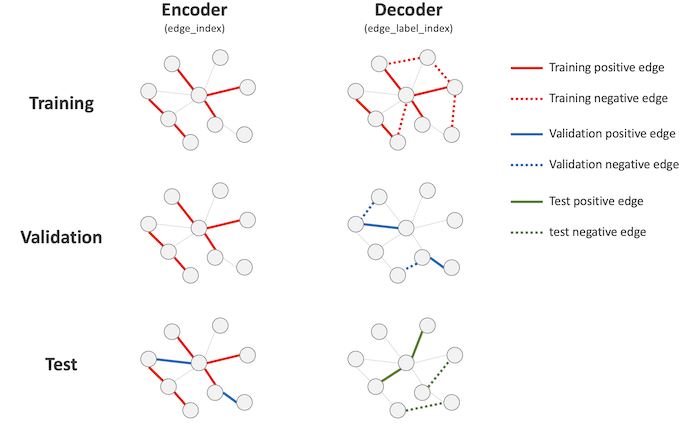

## 5- Drug Information Representation
---
**`Goal:`**
   * to encode the interactive information based on the `graph-structured data` with the `node content`

    * Both interactive `(intra-view)` and content information `(inter-view)` can be treated as two different views for a node in the graph.

**`Limitation:`**

* Most existing multi-view models apply naive view combination strategies, such as weighted average, add, and multi-view matrix factorization.
* Most of them are unsupervised and usually used to deal with the homogeneous network.

***GCN integrates the inter-view drug embedding vectors with the external DDI relationships.***


**In this experiments we evaluate the performance of `drug's information` embedding while using the `ddi graph structure`.**

The features that we use are `text-based information` of the drugs, including SMILES strings and Drug Description

### 5-1- No Feature

In [ ]:
def no_feature(smiles,DDI_graph):
  #DrugIDs_in_graph = np.unique(DDI_graph.values)
  features = np.ones((len(smiles),100))
  print('no_feature')
  return features,DDI_graph

### 5-2- SMILES-based embedding

#### 5-2-1- Morgan Fingerprint

In [ ]:
def Morgan(smiles,DDI_graph):
  featurizer = dc.feat.CircularFingerprint(size=100, radius=1)
  dataset=smiles['SMILES']
  features = pd.DataFrame(columns = [i for i in range(100)])
  for i in range(len(dataset)):
    features.loc[i] = featurizer.featurize(dataset[i])[0]
  print('Morgan')
  return features.values,DDI_graph

#### 5-2-2- Mol2vec


In [ ]:
def Mol2Vec(smiles,DDI_graph):
  featurizer = dc.feat.Mol2VecFingerprint()
  features=pd.DataFrame(columns = [i for i in range(300)])
  for s in smiles['SMILES']:
    features.loc[len(features)]=np.array(featurizer.featurize(s))[0]
  print('mol2vec')
  return features.values,DDI_graph

#### 5-2-3- SPVec

In [ ]:
def sentences2vec(sentences, model,dim):
    keys = set(model.wv.index_to_key)
    vec = pd.DataFrame(columns = [i for i in range(dim)])
    for sentence in sentences:
            vec.loc[len(vec)] = np.array(sum([model.wv[y] for y in sentence         if y in set(sentence) & keys]))
    return vec

In [ ]:
def character2vec(smiles,DDI_graph):
  tokenizer = BasicSmilesTokenizer()
  corpus=[]
  for s in smiles['SMILES']:
      corpus.append(tokenizer.tokenize(s))
  model= Word2Vec(corpus,
          vector_size=300,
          window=20,
          min_count=0,
          sg=1,
          epochs=5)
  aa_sentences = [tokenizer.tokenize(x) for x in smiles['SMILES']]
  vec=sentences2vec(aa_sentences, model,300)
  print('character2vec')
  return vec.values,DDI_graph

#### 5-2-4- Doc2vec
ref:[gensim](https://radimrehurek.com/gensim/models/doc2vec.html)

In [ ]:
def doc2vec(SMILES,DDI_graph):
  tagged_documents = [TaggedDocument(doc.split(), [i]) for i, doc in enumerate(SMILES['SMILES'])]

  model = Doc2Vec(tagged_documents, vector_size=100, min_count=1, epochs=20)

  feature = [model.infer_vector(doc.split()) for doc in SMILES['SMILES']]
  #feature=pd.DataFrame(embeddings,index=new_df['DrugBank ID'])
  print('doc2vec')
  return feature,DDI_graph

#### 5-2-5-Language models

In [ ]:
allowed_drug=list(df_valid_molecules['DrugBank ID'])+list(drugID_DESC['Drug ID'])
def LM(DDI_graph,allowed_drug,model_name,dir,s):
    Drug=pd.read_csv(dir, sep=s,index_col=0)
    if 'Unnamed: 0' in Drug.columns:
      Drug.drop(columns='Unnamed: 0', inplace=True)
    df = Drug[Drug.iloc[:, 0].isin(allowed_drug)]
    df=df.reset_index(drop=True)
    if 'Discription' in df.columns:
      features=df.drop(df.columns[[0, 1, 2]], axis=1)
    else:
      features=df.drop(df.columns[[0, 1]], axis=1)
    print(model_name)
    return  features.values, DDI_graph

##6- GCN (Multi-view representation Fusion)
---

1.   An encoder creates node embeddings by processing the graph with two
convolution layers.
2.   We randomly add negative links to the original graph. This makes the model task a binary classification with the positive links from the original edges and the negative links from the added edges.
3.   A decoder makes link predictions (i.e. binary classifications) on all the edges including the negative links using node embeddings.# Models


[Ref](https://github.com/pyg-team/pytorch_geometric/blob/master/examples/link_pred.py)

This setup is from [the original link prediction implementation in Variational Graph Auto-Encoders](https://github.com/tkipf/gae). The code looks like something below. This is adapted from [the code example in PyG repo](https://github.com/pyg-team/pytorch_geometric/blob/master/examples/link_pred.py) which is based on the Graph Auto-Encoders implementation.

The total number of the GCN encoder is 3.  To further regularise the model, dropout with 𝑝 = 0.3 is applied to every intermediate layer’s output.
[MIRACLE](https://arxiv.org/pdf/2010.11711.pdf)

In [ ]:
class Net(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, out_channels)
    def encode(self, x, edge_index):
        x=self.conv1(x, edge_index)
        x=F.dropout(x, p=0.3)
        x=F.relu(x)
        x=self.conv2(x, edge_index)
        x=F.dropout(x, p=0.3)
        x=F.relu(x)
        x=self.conv3(x, edge_index)
        return x

    def decode(self, z, edge_label_index):
        return (z[edge_label_index[0]] * z[edge_label_index[1]]).sum(
            dim=-1
        )  # product of a pair of nodes on each edge

    def decode_all(self, z):
        prob_adj = z @ z.t()
        return (prob_adj > 0).nonzero(as_tuple=False).t()

In [ ]:
def train():
    model.train()
    optimizer.zero_grad()

    z = model.encode(train_data.x, train_data.edge_index) # initializing GCN model
    out = model.decode(z, edge_label_index).view(-1)
    loss = criterion(out, edge_label)
    loss.backward()
    optimizer.step()
    scheduler.step()
    return loss


@torch.no_grad()
def test(data):
    model.eval()
    z = model.encode(data.x, data.edge_index)
    out = model.decode(z, data.edge_label_index).view(-1).sigmoid()
    roc=roc_auc_score(data.edge_label.cpu().numpy(), out.cpu().numpy())
    label=data.edge_label.cpu().numpy()
    score=out.cpu().numpy()
    return roc,label,score

##7- Training and Evaluation
---

We can now train and evaluate the model with the following code.




In [ ]:
Embedding_models={#'No Feature':no_feature(drugID_smiles_ddi,DDI_graph),
                  #'Morgan':Morgan(drugID_smiles_ddi,DDI_graph),
                  #'Mol2vec':Mol2Vec(drugID_smiles_ddi,DDI_graph),
                  #'SPVec':character2vec(drugID_smiles_ddi,DDI_graph),
                  #'Doc2vec':doc2vec(drugID_smiles_ddi,DDI_graph),
                  'ChemBertaSMILES':LM(DDI_graph,allowed_drug,'Chemberta+SMILES','/content/drive/MyDrive/Shaghayegh Sadeghi/Drug embedding/DrugBank SMILES Embedding/SMILES_Chemberta.csv',','),
                  'MolformerSMILES':LM(DDI_graph,allowed_drug,'Molformer+SMILES','/content/drive/MyDrive/Shaghayegh Sadeghi/Drug embedding/DrugBank SMILES Embedding/SMILES_Molformer.csv',','),

                  #'SBERTSMILES':LM(DDI_graph,allowed_drug,'SBERT+SMILES','/content/drive/MyDrive/Shaghayegh Sadeghi/Drug embedding/DrugBank SMILES Embedding/SBERT/SMILES_SBert.csv',','),
                  #'AngledBERTSMILES':LM(DDI_graph,allowed_drug,'AngledBERT+SMILES','/content/drive/MyDrive/Shaghayegh Sadeghi/Drug embedding/DrugBank SMILES Embedding/AngleBERT/SMILES_angleBert.csv',','),
                  #'GPTSMILES':LM(DDI_graph,allowed_drug,'GPT+SMILES','/content/drive/MyDrive/Shaghayegh Sadeghi/Drug embedding/DrugBank SMILES Embedding/GPT/SMILES_GPT.csv','\t'),
                  #'LLaMASMILES':LM(DDI_graph,allowed_drug,'LLaMA+SMILES','/content/drive/MyDrive/Shaghayegh Sadeghi/Drug embedding/DrugBank SMILES Embedding/LLaMA/llama65b_base_SMILES_embeddings.csv','\t'),
                  #'LLaMA2SMILES':LM(DDI_graph,allowed_drug,'LLaMA2+SMILES','/content/drive/MyDrive/Shaghayegh Sadeghi/Drug embedding/DrugBank SMILES Embedding/LLaMA II/llamaII7b_base_SMILES_embeddings.csv','\t'),
                  #'AngledLLaMA2SMILES':LM(DDI_graph,allowed_drug,'AngledLLaMA+SMILES','/content/drive/MyDrive/Shaghayegh Sadeghi/Drug embedding/DrugBank SMILES Embedding/AngleLLaMA/SMILES_angleLlama.csv',','),
                  #'BERTDesc':LM(DDI_graph,allowed_drug,'BERT+Desc','/content/drive/MyDrive/Shaghayegh Sadeghi/Drug embedding/DrugBank Description Embedding/BERT/bert50mt_base_Discription_embeddings.csv','\t'),
                  #'SBERTDesc':LM(DDI_graph,allowed_drug,'SBERT+Desc','/content/drive/MyDrive/Shaghayegh Sadeghi/Drug embedding/DrugBank Description Embedding/SBERT/Desc_SBert.csv',','),
                  #'AngledBERTDesc':LM(DDI_graph,allowed_drug,'AngledBERT+Desc','/content/drive/MyDrive/Shaghayegh Sadeghi/Drug embedding/DrugBank Description Embedding/AngleBERT/Drug_description_angleBERT.csv',','),
                  #'GPTDesc':LM(DDI_graph,allowed_drug,'GPT+Desc','/content/drive/MyDrive/Shaghayegh Sadeghi/Drug embedding/DrugBank Description Embedding/GPT/Dr_Desc_GPT.csv','\t'),
                  #'LLaMADesc':LM(DDI_graph,allowed_drug,'LLaMA+Desc','/content/drive/MyDrive/Shaghayegh Sadeghi/Drug embedding/DrugBank Description Embedding/LLaMA/llama65b_base_Discription_embeddings.csv','\t'),
                  #'LLaMA2Desc':LM(DDI_graph,allowed_drug,'LLaMA2+Desc','/content/drive/MyDrive/Shaghayegh Sadeghi/Drug embedding/DrugBank Description Embedding/LLaMA II/llamaII7b_base_Discription_embeddings.csv','\t'),
                  #'AngledLLaMA2Desc':LM(DDI_graph,allowed_drug,'AngledLLaMA+Desc','/content/drive/MyDrive/Shaghayegh Sadeghi/Drug embedding/DrugBank Description Embedding/AngleLLaMA/Drug_description_angleLlama.csv',','),
                  }

Chemberta+SMILES
Molformer+SMILES


We set each parameter group’s learning rate using an exponentially decaying schedule with the initial learning rate 0.0001
and multiplicative factor 0.96. [MIRACLE](https://arxiv.org/pdf/2010.11711.pdf)

In [ ]:
lmbda = lambda epoch: 0.96

In [ ]:
LR=[#0.01,0.001,
    0.0001
    #,0.0002,0.0003,0.00001
    ]


#modelname=['No Feature','Morgan','Mol2vec','SPVec','Doc2Vec',
         # 'BERTSMILES','SBERTSMILES','AngledBERTSMILES','GPTSMILES','LLaMASMILES','LLaMA2SMILES','AngledLLaMA2SMILES',
         # 'BERTDesc','SBERTDesc','AngledBERTDesc','GPTDesc','LLaMADesc','LLaMA2Desc','AngledLLaMA2Desc']


modelname=['BERTSMILES','BERTSMILES_token']
AUC=pd.DataFrame(columns = [#'0.01','0.001',
                            '0.0001'
                            #,'0.0002','0.0003','0.00001'
                            ])
PR=pd.DataFrame(columns = [#'0.01','0.001',
                            '0.0001'
                            #,'0.0002','0.0003','0.00001'
                            ])


AUC['Embedding']=modelname
PR['Embedding']=modelname

for l in LR:
  print('-------------------------------')
  print('=====Learning Rate:',l,'=======')
  print('-------------------------------')
  results_AUC=[]
  results_PR=[]
  for modelname, emb in Embedding_models.items():
    print('-------------------------------')
    print('=========',modelname,'=========')
    print('-------------------------------')
    data=PyG_data(emb[0],emb[1])
    train_data, val_data, test_data = transform(data)
    model = Net(data.num_features, 256, 256).to(device)
    optimizer = torch.optim.Adam(params=model.parameters(), lr=l)
    scheduler = MultiplicativeLR(optimizer, lr_lambda=lmbda)
    criterion = torch.nn.BCEWithLogitsLoss()
    '''
    neg_edge_index = negative_sampling(
          edge_index=train_data.edge_index, num_nodes=train_data.num_nodes,
          num_neg_samples=train_data.edge_label_index.size(1), method='sparse')'''
    struct_neg_tup=structured_negative_sampling(edge_index=train_data.edge_index,num_nodes=train_data.num_nodes,contains_neg_self_loops = False)
    neg_edge_index = torch.stack((struct_neg_tup[0], struct_neg_tup[2]), dim=0)
    neg_edge_index, _ = torch.unique(neg_edge_index, dim=1, return_inverse=True)

    edge_label_index = torch.cat(
          [train_data.edge_label_index, neg_edge_index],
          dim=-1,
      )
    edge_label = torch.cat([
          train_data.edge_label,
          train_data.edge_label.new_zeros(neg_edge_index.size(1))
      ], dim=0)
    best_val_auc = final_test_auc = 0
    for epoch in range(1, 100):
        loss = train()
        val_auc = test(val_data)[0]
        test_auc = test(test_data)[0]
        label=test(test_data)[1]
        score=test(test_data)[2]
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            final_test_auc = test_auc
            best_scores=score
        print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}, Val: {val_auc:.4f}')

    precision, recall, thresholds = precision_recall_curve(label, best_scores)
    pr=auc(recall, precision)
    results_AUC.append({"Embedding":modelname,"AUC":final_test_auc})
    results_PR.append({"Embedding":modelname,"PR_AUC": pr})
    del data
    del model

  #AUC[str(l)]=results_AUC['AUC']
  #PR[str(l)]=results_PR['PR_AUC']

-------------------------------
=====Learning Rate: 0.0001 =======
-------------------------------
-------------------------------
========= ChemBertaSMILES =========
-------------------------------
Epoch: 001, Loss: 5.7943, Val: 0.5372
Epoch: 002, Loss: 5.0890, Val: 0.5440
Epoch: 003, Loss: 4.4817, Val: 0.5251
Epoch: 004, Loss: 3.9514, Val: 0.5191
Epoch: 005, Loss: 3.5319, Val: 0.5149
Epoch: 006, Loss: 3.1682, Val: 0.5046
Epoch: 007, Loss: 2.8295, Val: 0.5032
Epoch: 008, Loss: 2.5562, Val: 0.5046
Epoch: 009, Loss: 2.3442, Val: 0.4780
Epoch: 010, Loss: 2.1624, Val: 0.4981
Epoch: 011, Loss: 1.9324, Val: 0.4662
Epoch: 012, Loss: 1.8332, Val: 0.4761
Epoch: 013, Loss: 1.6729, Val: 0.4683
Epoch: 014, Loss: 1.5662, Val: 0.4612
Epoch: 015, Loss: 1.4833, Val: 0.4505
Epoch: 016, Loss: 1.3993, Val: 0.4489
Epoch: 017, Loss: 1.3195, Val: 0.4543
Epoch: 018, Loss: 1.2595, Val: 0.4257
Epoch: 019, Loss: 1.2057, Val: 0.4481
Epoch: 020, Loss: 1.1662, Val: 0.4359
Epoch: 021, Loss: 1.1258, Val: 0.4406
Epo

In [ ]:
results_AUC

[{'Embedding': 'ChemBertaSMILES', 'AUC': 0.5277610503617672},
 {'Embedding': 'MolformerSMILES', 'AUC': 0.5505789467847131}]

In [ ]:
results_PR

[{'Embedding': 'ChemBertaSMILES', 'PR_AUC': 0.5477021321661133},
 {'Embedding': 'MolformerSMILES', 'PR_AUC': 0.7012339443480431}]

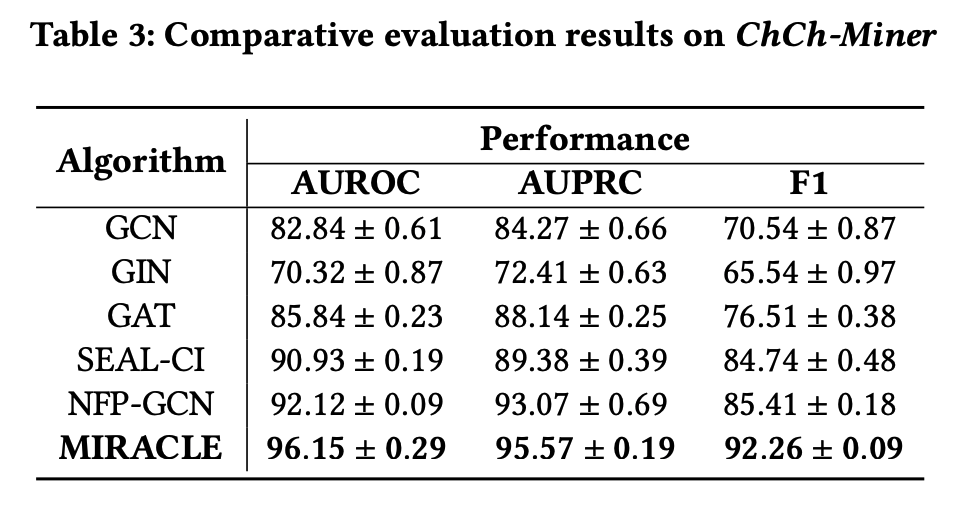

## 8- Results

In [ ]:
PR.to_csv('/content/drive/MyDrive/Shaghayegh Sadeghi/DDI_LM/PR_BioSnap_Struc_v2.csv')

In [ ]:
AUC.to_csv('/content/drive/MyDrive/Shaghayegh Sadeghi/DDI_LM/AUC_BioSnap_Struc_v2.csv')


In [ ]:
AUC

,0.01,0.001,0.0001,0.0002,0.0003,0.00001,Embedding,1e-05
Embedding,,,,,,,,
No Feature,0.870820,0.878083,0.866790,0.869988,0.883985,NaN,No Feature,0.809193
Morgan,0.858215,0.879767,0.876717,0.881502,0.890149,NaN,Morgan,0.864529
Mol2vec,0.825474,0.857605,0.515914,0.873104,0.896652,NaN,Mol2vec,0.500000
SPVec,0.859256,0.868501,0.748596,0.878075,0.883120,NaN,SPVec,0.500000
Doc2Vec,0.859486,0.851839,0.859262,0.867418,0.867495,NaN,Doc2Vec,0.822618
BERTSMILES,0.622741,0.632631,0.573537,0.651471,0.661590,NaN,BERTSMILES,0.562887
SBERTSMILES,0.863227,0.844116,0.783706,0.903429,0.803955,NaN,SBERTSMILES,0.191435
AngledBERTSMILES,0.633699,0.617447,0.589458,0.569789,0.685924,NaN,AngledBERTSMILES,0.616299
GPTSMILES,0.761799,0.984039,0.864590,0.967822,0.974085,NaN,GPTSMILES,0.626035


In [ ]:
AUC=pd.read_csv('/content/drive/MyDrive/Shaghayegh Sadeghi/DDI_LM/AUC_BioSnap_Struc_v2.csv',index_col=[0])

AUC.index=AUC['Embedding']
AUC_edited=AUC.drop(['0.00001','Embedding'],axis=1)
model=['GPTSMILES','LLaMASMILES','LLaMA2SMILES']
AUC_edited_f= AUC_edited[AUC_edited.index.isin(model)]
AUC_edited_f.index=['GPT','LLaMA','LLaMA2']

In [ ]:
AUC_edited_f

,0.01,0.001,0.0001,0.0002,0.0003,1e-05
GPT,0.900030,0.980421,0.857324,0.975308,0.976241,0.617398
LLaMA,0.645546,0.975275,0.932155,0.957277,0.955334,0.552075
LLaMA2,0.886154,0.976425,0.943826,0.939557,0.950906,0.642625


In [ ]:
PR=pd.read_csv('/content/drive/MyDrive/Shaghayegh Sadeghi/DDI_LM/PR_BioSnap_Struc_v2.csv',index_col=[0])
PR.index=AUC['Embedding']
PR_edited=PR.drop(['0.00001','Embedding'],axis=1)
PR_edited_f= PR_edited[PR_edited.index.isin(model)]
PR_edited_f.index=['GPT','LLaMA','LLaMA2']

In [ ]:
import matplotlib.pyplot as plt

# Disable LaTeX rendering
plt.rcParams['text.usetex'] = False

In [ ]:
plt.clf()


<Figure size 640x480 with 0 Axes>

In [ ]:
df = pd.DataFrame(AUC_edited_f)
df

,0.01,0.001,0.0001,0.0002,0.0003,1e-05
Embedding,,,,,,
GPTSMILES,0.900030,0.980421,0.857324,0.975308,0.976241,0.617398
LLaMASMILES,0.645546,0.975275,0.932155,0.957277,0.955334,0.552075
LLaMA2SMILES,0.886154,0.976425,0.943826,0.939557,0.950906,0.642625


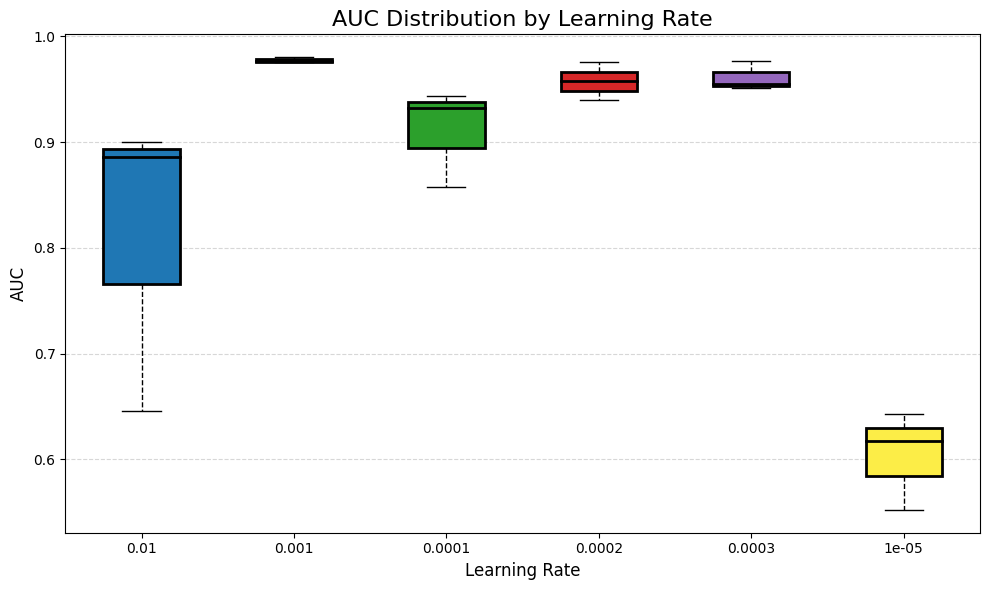

In [ ]:
df = pd.DataFrame(AUC_edited_f)


box_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd','#fced47']

plt.figure(figsize=(10, 6))
bp = plt.boxplot(df.values, patch_artist=True, boxprops=dict(facecolor='white', edgecolor='black'))

for box, color in zip(bp['boxes'], box_colors):
    box.set(color='black', linewidth=2)
    box.set(facecolor=color)

for whisker in bp['whiskers']:
    whisker.set(color='black', linestyle='--', linewidth=1)

for median in bp['medians']:
    median.set(color='black', linewidth=2)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.title('AUC Distribution by Learning Rate', fontsize=16)
plt.xlabel('Learning Rate', fontsize=12)
plt.ylabel('AUC', fontsize=12)

plt.xticks(range(1, len(df.columns) + 1), df.columns, fontsize=10)


plt.tight_layout()
plt.savefig("AUC Distribution by Learning Rate_biosnap.pdf", format="pdf", bbox_inches="tight")

plt.show()




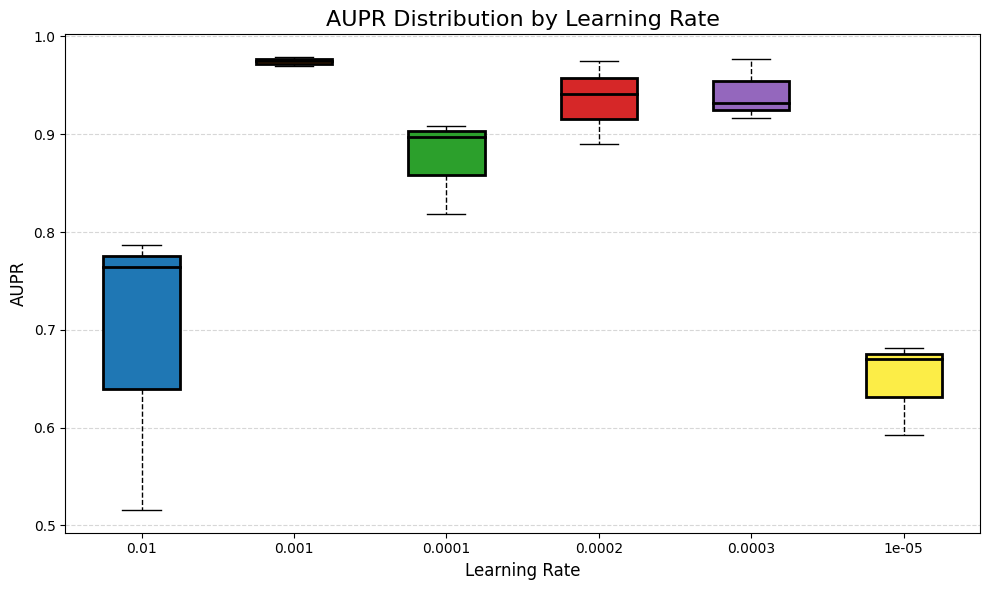

In [ ]:
df = pd.DataFrame(PR_edited_f)


box_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd','#fced47']


plt.figure(figsize=(10, 6))
bp = plt.boxplot(df.values, patch_artist=True, boxprops=dict(facecolor='white', edgecolor='black'))


for box, color in zip(bp['boxes'], box_colors):
    box.set(color='black', linewidth=2)
    box.set(facecolor=color)


for whisker in bp['whiskers']:
    whisker.set(color='black', linestyle='--', linewidth=1)

for median in bp['medians']:
    median.set(color='black', linewidth=2)


plt.grid(axis='y', linestyle='--', alpha=0.5)


plt.title('AUPR Distribution by Learning Rate', fontsize=16)
plt.xlabel('Learning Rate', fontsize=12)
plt.ylabel('AUPR', fontsize=12)

plt.xticks(range(1, len(df.columns) + 1), df.columns, fontsize=10)


plt.tight_layout()
plt.savefig("AUPR Distribution by Learning Rate_biosnap.pdf", format="pdf", bbox_inches="tight")

plt.show()

In [ ]:
sns.set_style("whitegrid")
sns.set_palette("Set1")

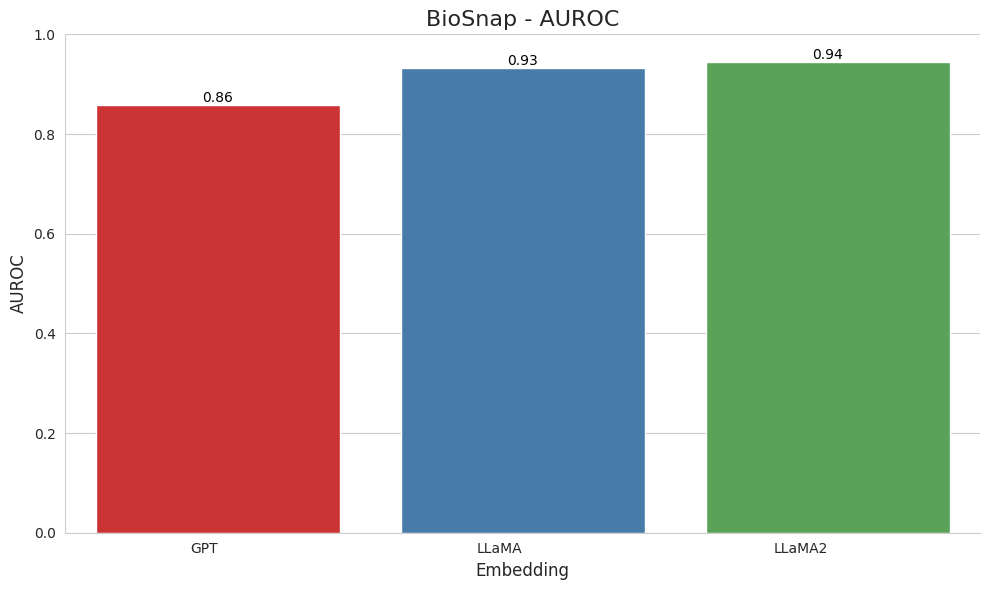

In [ ]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=AUC_edited_f.index, y='0.0001', data=AUC_edited_f)
sns.set_style("whitegrid")
sns.set_palette("Set1")
plt.title('BioSnap - AUROC', fontsize=16)
plt.xlabel('Embedding', fontsize=12)
plt.ylabel('AUROC', fontsize=12)
plt.ylim(0, 1)

ax.set_xticklabels(ax.get_xticklabels(), ha='right', fontsize=10)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("BioSnap - AUROC.pdf", format="pdf", bbox_inches="tight")

plt.show()

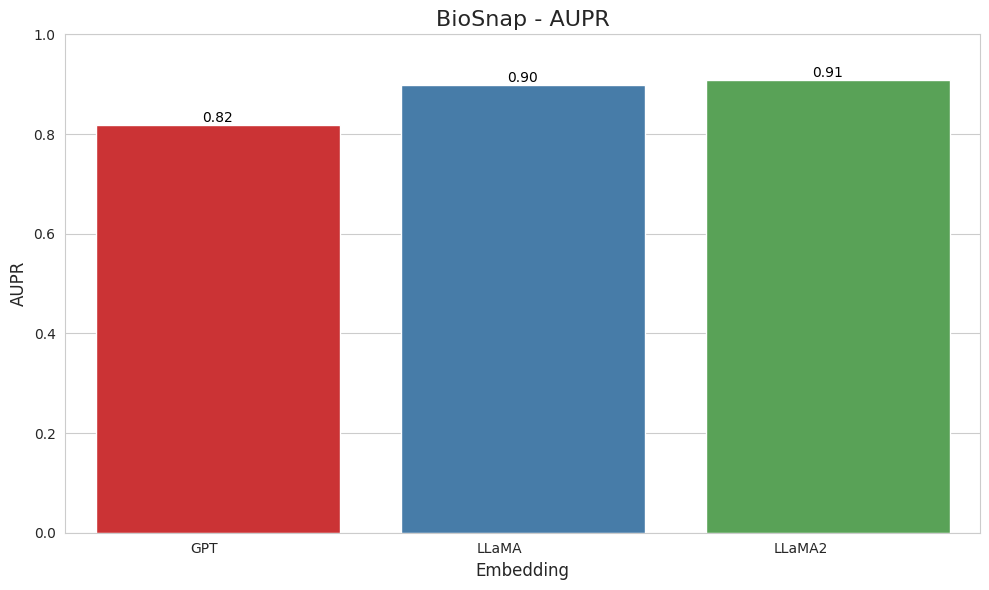

In [ ]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=PR_edited_f.index, y='0.0001', data=PR_edited_f)


plt.title('BioSnap - AUPR', fontsize=16)
plt.xlabel('Embedding', fontsize=12)
plt.ylabel('AUPR', fontsize=12)
plt.ylim(0, 1)

ax.set_xticklabels(ax.get_xticklabels(), ha='right', fontsize=10)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')

#ax.spines['top'].set_visible(False)
#ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("BioSnap - AUPR.pdf", format="pdf", bbox_inches="tight")

plt.show()







<ipython-input-24-18e4c5339d59>:14: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(AUC_edited.index, rotation=45, ha='right', fontsize=10)


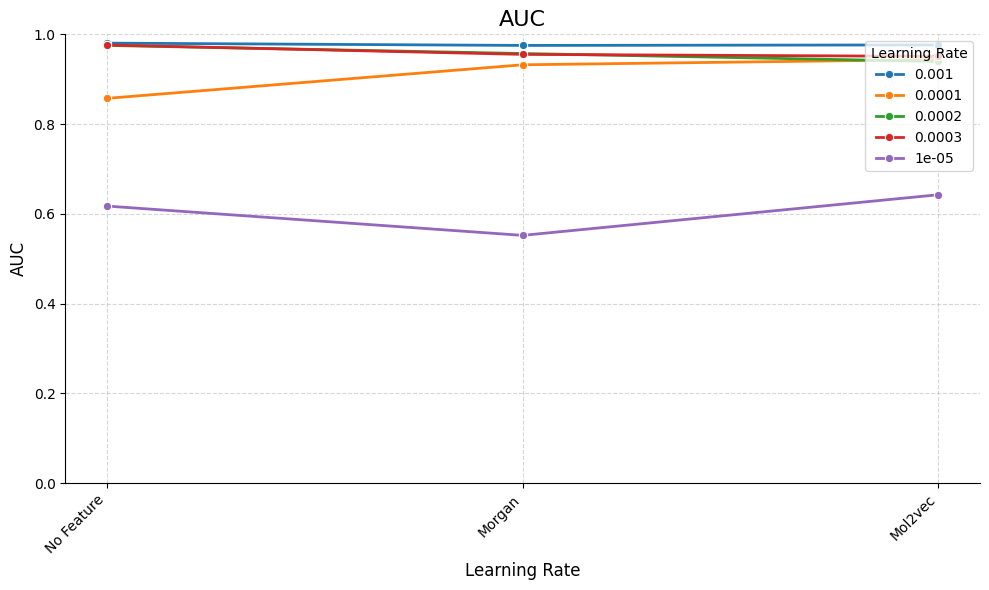

In [ ]:

# Create a Seaborn line plot with multiple lines for each column
plt.figure(figsize=(10, 6))

# Iterate through additional columns and plot them as separate lines
for col in AUC_edited_f.columns[1:]:
    ax = sns.lineplot(data=AUC_edited_f, x=AUC_edited_f.index, y=col, marker='o', label=col, linewidth=2)

# Customize the plot
plt.title('AUC', fontsize=16)
plt.xlabel('Learning Rate', fontsize=12)
plt.ylabel('AUC', fontsize=12)
plt.ylim(0, 1)  # Adjust the y-axis limits as needed

ax.set_xticklabels(AUC_edited.index, rotation=45, ha='right', fontsize=10)

# Customize tick label font size
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Add a legend
plt.legend(title='Learning Rate', loc='upper right')

# Add a grid
plt.grid(True, linestyle='--', alpha=0.5)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("BioSnap - AUC-line.pdf", format="pdf", bbox_inches="tight")

plt.show()



<ipython-input-15-c7d055607bc5>:14: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(PR_edited.index, rotation=45, ha='right', fontsize=10)


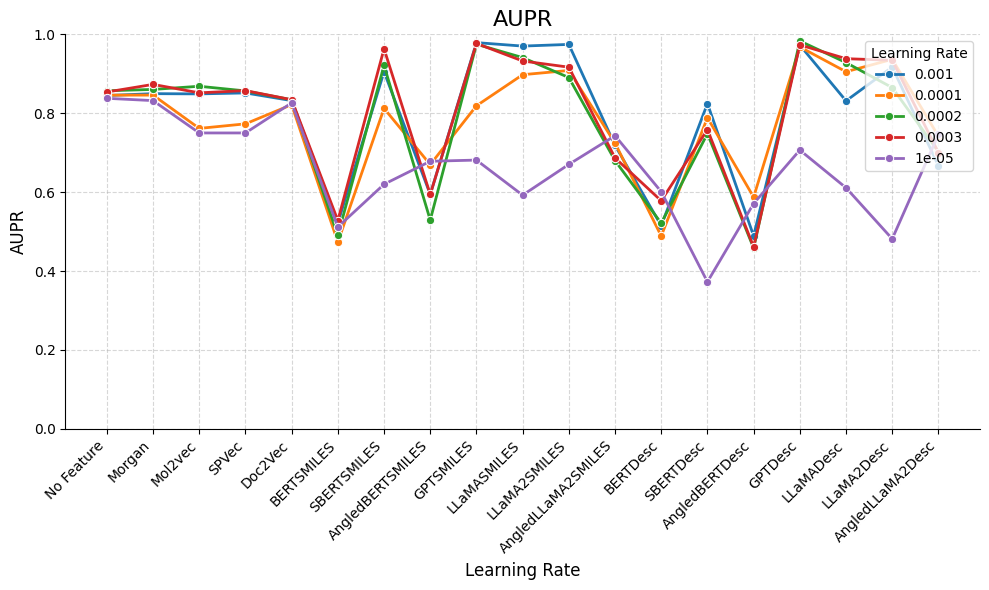

In [ ]:

# Create a Seaborn line plot with multiple lines for each column
plt.figure(figsize=(10, 6))

# Iterate through additional columns and plot them as separate lines
for col in PR_edited.columns[1:]:
    ax = sns.lineplot(data=PR_edited, x='Embedding', y=col, marker='o', label=col, linewidth=2)

# Customize the plot
plt.title('AUPR', fontsize=16)
plt.xlabel('Learning Rate', fontsize=12)
plt.ylabel('AUPR', fontsize=12)
plt.ylim(0, 1)  # Adjust the y-axis limits as needed

ax.set_xticklabels(PR_edited.index, rotation=45, ha='right', fontsize=10)

# Customize tick label font size
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Add a legend
plt.legend(title='Learning Rate', loc='upper right')

# Add a grid
plt.grid(True, linestyle='--', alpha=0.5)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("BioSnap - AUPR-line.pdf", format="pdf", bbox_inches="tight")

plt.show()

